# ruGPT-3 + LoRA V3 Tuned: улучшенная версия

Базируется на `llm_detection_3.ipynb` (V3), но с подкрученными гиперпараметрами.

**Анализ ошибок V3** (confusion matrix):
- FP (фейк пропущен как реальная): **17** -- главная проблема
- FN (реальная заблокирована как фейк): **3** -- почти идеально

Модель слишком "доверчива" к фейкам. Исправляем через **взвешенный loss** (weight для класса "фейк" = 1.3).

| Параметр | V3 (оригинал) | V3 Tuned |
|----------|--------------|----------|
| max_length | 384 | 512 |
| LoRA r | 64 | 64 |
| LoRA alpha | 128 | 128 |
| LoRA dropout | 0.05 | 0.1 |
| target_modules | c_attn, c_proj, c_fc | c_attn, c_proj, c_fc |
| effective batch | 64 | 64 |
| LR | 1e-4 | 5e-5 |
| warmup | 10% | 15% |
| epochs | 12 | 15 |
| patience | 6 | 5 |
| label_smoothing | 0.03 | 0.05 |
| class weights | нет | **[1.3, 1.0]** (фейк vs реальная) |

In [1]:
!pip install peft accelerate -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix,
)

n_threads = os.cpu_count() or 4
torch.set_num_threads(n_threads)
torch.set_num_interop_threads(min(n_threads, 4))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE} | CPU threads: {torch.get_num_threads()}')

c:\Users\pozoy\Desktop\MISIS\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | CPU threads: 12


In [3]:
DATA_PATH      = '../../data/ready_dataset.csv'
HEADLINE_COL   = 'headline_clean'
BODY_COL       = 'body_clean'
LABEL_COL      = 'label'

MODEL_NAME     = 'ai-forever/rugpt3small_based_on_gpt2'
MAX_LENGTH     = 512
BATCH_SIZE     = 4         # меньше из-за max_length=512
GRAD_ACCUM     = 16        # effective batch = 64
EPOCHS         = 15
LR             = 5e-5
WEIGHT_DECAY   = 0.02
PATIENCE       = 5
LABEL_SMOOTH   = 0.05
MAX_HOURS      = 24.0

# Веса классов: штраф за пропуск фейков (FP в V3 = 17, FN = 3)
# class 0 = фейк, class 1 = реальная
CLASS_WEIGHTS  = [1.3, 1.0]

LORA_R         = 64
LORA_ALPHA     = 128
LORA_DROPOUT   = 0.1
TARGET_MODULES = ['c_attn', 'c_proj', 'c_fc']

OUTPUT_DIR     = '../../models/llm_v3_tuned'
ADAPTER_DIR    = os.path.join(OUTPUT_DIR, 'lora_adapter')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Model:         {MODEL_NAME}')
print(f'max_length:    {MAX_LENGTH}')
print(f'LoRA r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}, modules={TARGET_MODULES}')
print(f'Effective BS:  {BATCH_SIZE * GRAD_ACCUM}')
print(f'Epochs: {EPOCHS}, patience={PATIENCE}, LR={LR}')
print(f'Label smoothing: {LABEL_SMOOTH}')
print(f'Class weights:   {CLASS_WEIGHTS} (fake, real)')
print(f'Time limit: {MAX_HOURS}h')

Model:         ai-forever/rugpt3small_based_on_gpt2
max_length:    512
LoRA r=64, alpha=128, dropout=0.1, modules=['c_attn', 'c_proj', 'c_fc']
Effective BS:  64
Epochs: 15, patience=5, LR=5e-05
Label smoothing: 0.05
Class weights:   [1.3, 1.0] (fake, real)
Time limit: 24.0h


## 1. Данные

Тот же split: 80/10/10, seed=42, stratified.

In [4]:
df = pd.read_csv(DATA_PATH)
df = df[[HEADLINE_COL, BODY_COL, LABEL_COL]].dropna()
df[HEADLINE_COL] = df[HEADLINE_COL].astype(str).str.strip()
df[BODY_COL]     = df[BODY_COL].astype(str).str.strip()
df = df[(df[HEADLINE_COL] != '') & (df[BODY_COL] != '')]
df[LABEL_COL]    = pd.to_numeric(df[LABEL_COL], errors='coerce').astype(int)

train_val, test_df = train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df[LABEL_COL],
)
train_df, val_df = train_test_split(
    train_val, test_size=0.1 / 0.9,
    random_state=SEED, stratify=train_val[LABEL_COL],
)
for d in (train_df, val_df, test_df):
    d.reset_index(drop=True, inplace=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'Balance: {dict(train_df[LABEL_COL].value_counts())}')

Train: 3525, Val: 441, Test: 441
Balance: {0: np.int64(1776), 1: np.int64(1749)}


## 2. Tokenization

Format: `"headline | body"`, truncation to 512 tokens.

In [5]:
class NewsDataset(Dataset):
    def __init__(self, headlines, bodies, labels, tokenizer, max_length):
        texts = [f"{h} | {b}" for h, b in zip(headlines, bodies)]
        self.encodings = tokenizer(
            texts, truncation=True, max_length=max_length,
            padding='max_length', return_tensors='pt',
        )
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Tokenization (max_length={MAX_LENGTH})...')
t0 = time.time()

train_dataset = NewsDataset(
    train_df[HEADLINE_COL].tolist(), train_df[BODY_COL].tolist(),
    train_df[LABEL_COL].values, tokenizer, MAX_LENGTH,
)
val_dataset = NewsDataset(
    val_df[HEADLINE_COL].tolist(), val_df[BODY_COL].tolist(),
    val_df[LABEL_COL].values, tokenizer, MAX_LENGTH,
)
test_dataset = NewsDataset(
    test_df[HEADLINE_COL].tolist(), test_df[BODY_COL].tolist(),
    test_df[LABEL_COL].values, tokenizer, MAX_LENGTH,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Done in {time.time()-t0:.1f}s')
print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

Tokenization (max_length=512)...
Done in 1.9s
Batches: train=882, val=111, test=111


## 3. Model

ruGPT-3 small (125M) + LoRA on three modules:
- `c_attn` -- QKV projections
- `c_proj` -- output projection
- `c_fc` -- MLP first layer

In [6]:
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
base_model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    modules_to_save=['score'],
)

model = get_peft_model(base_model, lora_config)
model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Total: {total:,}, trainable: {trainable:,} ({100*trainable/total:.2f}%)')
model.print_trainable_parameters()

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total: 134,671,872, trainable: 9,438,720 (7.01%)
trainable params: 9,438,720 || all params: 134,671,872 || trainable%: 7.0087


## 4. Training

Cosine schedule + 15% warmup, gradient clipping, label smoothing.

In [7]:
opt_steps_per_epoch = len(train_loader) // GRAD_ACCUM
total_opt_steps = opt_steps_per_epoch * EPOCHS
warmup_steps = int(total_opt_steps * 0.15)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps,
)

# Взвешенный loss: штрафуем пропуск фейков (class 0) сильнее
class_weights = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)

print(f'Opt steps/epoch: {opt_steps_per_epoch}, total: {total_opt_steps}, warmup: {warmup_steps}')
print(f'Loss weights: fake={CLASS_WEIGHTS[0]}, real={CLASS_WEIGHTS[1]}')

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0
    for batch in loader:
        ids    = batch['input_ids'].to(DEVICE)
        masks  = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        outputs = model(input_ids=ids, attention_mask=masks)
        total_loss += loss_fn(outputs.logits, labels).item()
        probs = torch.softmax(outputs.logits, dim=-1).cpu()
        all_preds.extend(probs.argmax(dim=-1).numpy())
        all_labels.extend(batch['labels'].numpy())
        all_probs.extend(probs.numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    return {
        'loss': total_loss / len(loader),
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted'),
        'recall': recall_score(labels, preds, average='weighted'),
        'preds': preds, 'labels': labels, 'probs': np.array(all_probs),
    }

history = []
best_f1 = 0.0
no_improve = 0
t_start = time.time()

print(f'\nTraining ruGPT-3 + LoRA Tuned (r={LORA_R}, modules={TARGET_MODULES})')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    elapsed_h = (time.time() - t_start) / 3600
    if elapsed_h > MAX_HOURS:
        print(f'Time limit {MAX_HOURS}h reached, stopping.')
        break

    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')

    for step, batch in enumerate(pbar):
        ids    = batch['input_ids'].to(DEVICE)
        masks  = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        loss = loss_fn(model(input_ids=ids, attention_mask=masks).logits, labels) / GRAD_ACCUM
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        pbar.set_postfix(loss=f'{loss.item() * GRAD_ACCUM:.4f}')

    if len(train_loader) % GRAD_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    avg_loss = epoch_loss / len(train_loader)
    val_result = evaluate(model, val_loader)

    history.append({
        'epoch': epoch,
        'train_loss': avg_loss,
        'val_loss': val_result['loss'],
        'val_acc': val_result['accuracy'],
        'val_f1': val_result['f1'],
    })

    elapsed = time.time() - t_start
    eta = elapsed / epoch * (EPOCHS - epoch)
    print(f'  Ep {epoch:2d} | loss={avg_loss:.4f} | val_loss={val_result["loss"]:.4f} | '
          f'val_acc={val_result["accuracy"]:.4f} | val_f1={val_result["f1"]:.4f} | '
          f'{elapsed/60:.0f}min (ETA {eta/60:.0f}min)')

    if val_result['f1'] > best_f1:
        best_f1 = val_result['f1']
        no_improve = 0
        model.save_pretrained(ADAPTER_DIR)
        tokenizer.save_pretrained(ADAPTER_DIR)
        print(f'  -> Saved (val_f1={best_f1:.4f})')
    else:
        no_improve += 1
        print(f'  -- no improvement ({no_improve}/{PATIENCE})')
        if no_improve >= PATIENCE:
            print(f'  -> Early stop')
            break

total_time = time.time() - t_start
print(f'\nTotal: {total_time/60:.1f} min ({total_time/3600:.1f} h)')

Opt steps/epoch: 55, total: 825, warmup: 123
Loss weights: fake=1.3, real=1.0

Training ruGPT-3 + LoRA Tuned (r=64, modules=['c_attn', 'c_proj', 'c_fc'])


Epoch 1/15: 100%|██████████| 882/882 [3:38:12<00:00, 14.84s/it, loss=0.7914]     


  Ep  1 | loss=0.6768 | val_loss=0.5966 | val_acc=0.7007 | val_f1=0.7001 | 222min (ETA 3111min)
  -> Saved (val_f1=0.7001)


Epoch 2/15: 100%|██████████| 882/882 [2:43:35<00:00, 11.13s/it, loss=0.1493]  


  Ep  2 | loss=0.4710 | val_loss=0.4466 | val_acc=0.8503 | val_f1=0.8471 | 390min (ETA 2533min)
  -> Saved (val_f1=0.8471)


...

  -> Saved (val_f1=0.9705)


Epoch 8/15: 100%|██████████| 882/882 [2:39:31<00:00, 10.85s/it, loss=0.1069]  


  Ep  8 | loss=0.1675 | val_loss=0.2372 | val_acc=0.9524 | val_f1=0.9523 | 1370min (ETA 1199min)
  -- no improvement (1/5)


Epoch 9/15: 100%|██████████| 882/882 [3:55:54<00:00, 16.05s/it, loss=0.1448]  


  Ep  9 | loss=0.1621 | val_loss=0.2333 | val_acc=0.9433 | val_f1=0.9431 | 1611min (ETA 1074min)
  -- no improvement (2/5)
Time limit 24.0h reached, stopping.

Total: 1611.0 min (26.9 h)


## 5. Test

Best checkpoint on test set.

In [9]:
from peft import PeftModel

best_base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
best_base.config.pad_token_id = tokenizer.pad_token_id
best_model = PeftModel.from_pretrained(best_base, ADAPTER_DIR)
best_model.to(DEVICE)
best_model.eval()

test_result = evaluate(best_model, test_loader)

test_metrics = {
    'accuracy':  test_result['accuracy'],
    'f1':        test_result['f1'],
    'precision': test_result['precision'],
    'recall':    test_result['recall'],
}

print('Test results:')
for k, v in test_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

print(f'\n{classification_report(test_result["labels"], test_result["preds"], target_names=["Fake", "Real"])}')

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test results:
  accuracy    : 0.9705
  f1          : 0.9705
  precision   : 0.9713
  recall      : 0.9705

              precision    recall  f1-score   support

        Fake       0.99      0.95      0.97       222
        Real       0.95      0.99      0.97       219

    accuracy                           0.97       441
   macro avg       0.97      0.97      0.97       441
weighted avg       0.97      0.97      0.97       441



## 6. Plots

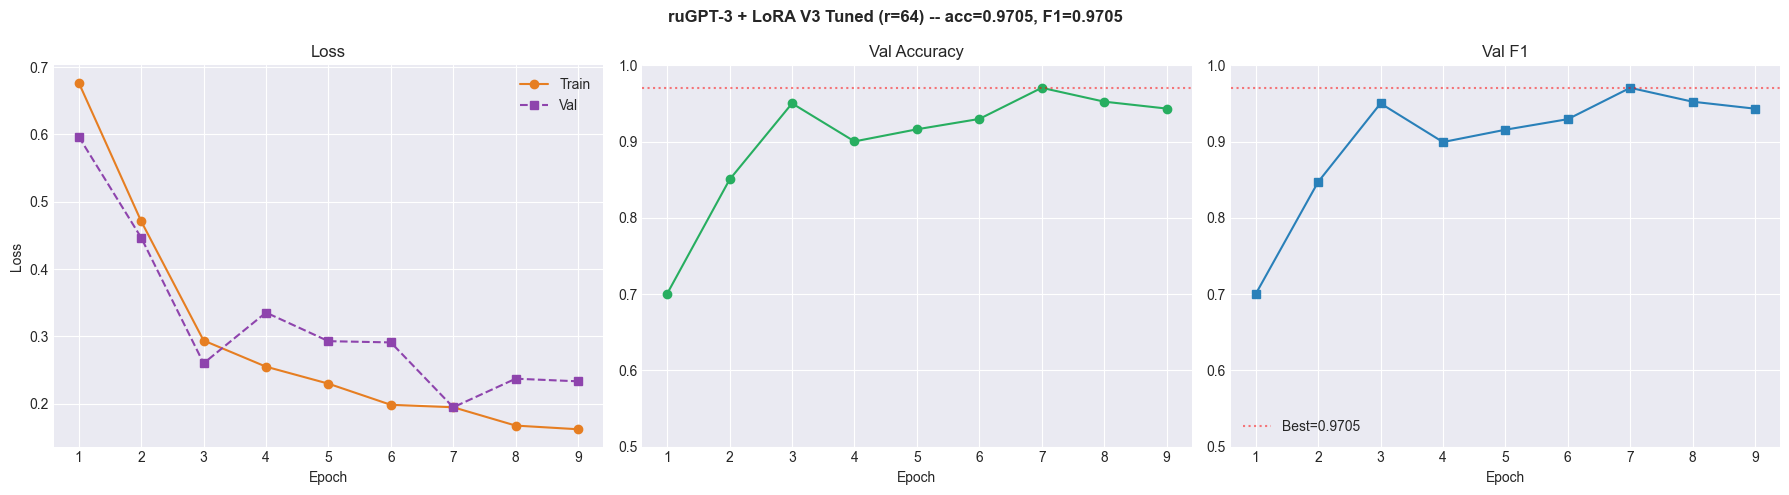

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = [h['epoch'] for h in history]

axes[0].plot(epochs_x, [h['train_loss'] for h in history], 'o-', color='#e67e22', label='Train')
axes[0].plot(epochs_x, [h['val_loss'] for h in history], 's--', color='#8e44ad', label='Val')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend()

axes[1].plot(epochs_x, [h['val_acc'] for h in history], 'o-', color='#27ae60')
axes[1].axhline(max(h['val_acc'] for h in history), color='red', ls=':', alpha=0.5)
axes[1].set(title='Val Accuracy', xlabel='Epoch', ylim=(0.5, 1.0))

axes[2].plot(epochs_x, [h['val_f1'] for h in history], 's-', color='#2980b9')
axes[2].axhline(best_f1, color='red', ls=':', alpha=0.5, label=f'Best={best_f1:.4f}')
axes[2].set(title='Val F1', xlabel='Epoch', ylim=(0.5, 1.0))
axes[2].legend()

plt.suptitle(
    f'ruGPT-3 + LoRA V3 Tuned (r={LORA_R}) -- acc={test_metrics["accuracy"]:.4f}, F1={test_metrics["f1"]:.4f}',
    fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

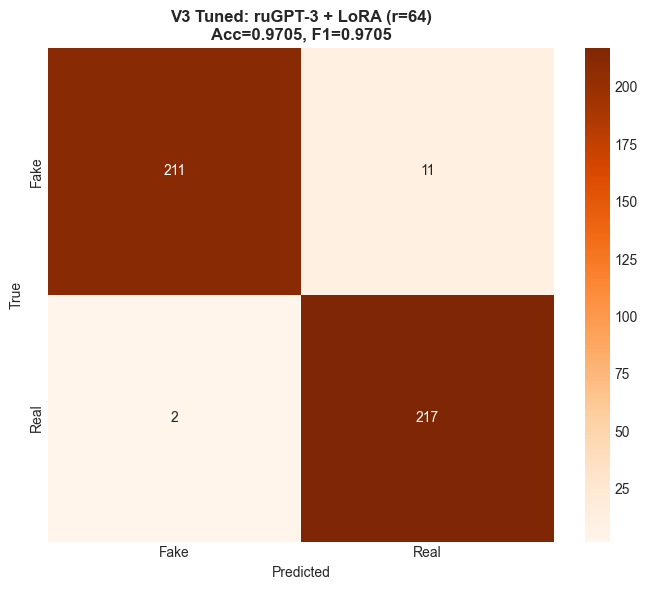

In [11]:
cm = confusion_matrix(test_result['labels'], test_result['preds'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'], ax=ax)
ax.set_title(f'V3 Tuned: ruGPT-3 + LoRA (r={LORA_R})\nAcc={test_metrics["accuracy"]:.4f}, F1={test_metrics["f1"]:.4f}',
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparison with previous models

In [12]:
comparison_data = []

# V1
if os.path.exists('../../models/llm/metrics.json'):
    with open('../../models/llm/metrics.json') as f:
        m = json.load(f)
        v1 = m.get('rugpt3_lora', {})
        if v1:
            comparison_data.append({
                'Model': 'ruGPT-3 + LoRA (V1)', 'Method': 'LLM',
                'Accuracy': v1['accuracy'], 'F1': v1['f1'],
                'Precision': v1['precision'], 'Recall': v1['recall'],
            })

# V2
if os.path.exists('../../models/llm_v2/metrics.json'):
    with open('../../models/llm_v2/metrics.json') as f:
        m = json.load(f)
        e = m.get('ensemble', {})
        if e:
            comparison_data.append({
                'Model': 'Frozen GPT + Sklearn (V2)', 'Method': 'LLM',
                'Accuracy': e['accuracy'], 'F1': e['f1'],
                'Precision': e['precision'], 'Recall': e['recall'],
            })

# V3 original
if os.path.exists('../../models/llm_v3/metrics.json'):
    with open('../../models/llm_v3/metrics.json') as f:
        m = json.load(f)['test']
        comparison_data.append({
            'Model': 'ruGPT-3 + LoRA (V3)', 'Method': 'LLM',
            'Accuracy': m['accuracy'], 'F1': m['f1'],
            'Precision': m['precision'], 'Recall': m['recall'],
        })

# RuBERT
if os.path.exists('../../models/rubert/metrics.json'):
    with open('../../models/rubert/metrics.json') as f:
        m = json.load(f)['rubert']
        comparison_data.append({
            'Model': 'RuBERT (fine-tuned)', 'Method': 'Transformer',
            'Accuracy': m['test_acc'], 'F1': m['test_f1'],
            'Precision': m['test_precision'], 'Recall': m['test_recall'],
        })

# V3 Tuned (this notebook)
comparison_data.append({
    'Model': 'ruGPT-3 + LoRA (V3 Tuned)', 'Method': 'LLM (V3T)',
    'Accuracy': test_metrics['accuracy'], 'F1': test_metrics['f1'],
    'Precision': test_metrics['precision'], 'Recall': test_metrics['recall'],
})

comparison_df = pd.DataFrame(comparison_data).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df.index += 1
print(comparison_df.to_string())

                       Model       Method  Accuracy        F1  Precision    Recall
1        ruGPT-3 + LoRA (V3)          LLM  0.972789  0.972789   0.972789  0.972789
2  ruGPT-3 + LoRA (V3 Tuned)    LLM (V3T)  0.970522  0.970513   0.971315  0.970522
3        RuBERT (fine-tuned)  Transformer  0.970522  0.970655   0.959821  0.981735
4        ruGPT-3 + LoRA (V1)          LLM  0.947846  0.947790   0.949388  0.947846
5  Frozen GPT + Sklearn (V2)          LLM  0.897959  0.897938   0.898148  0.897959


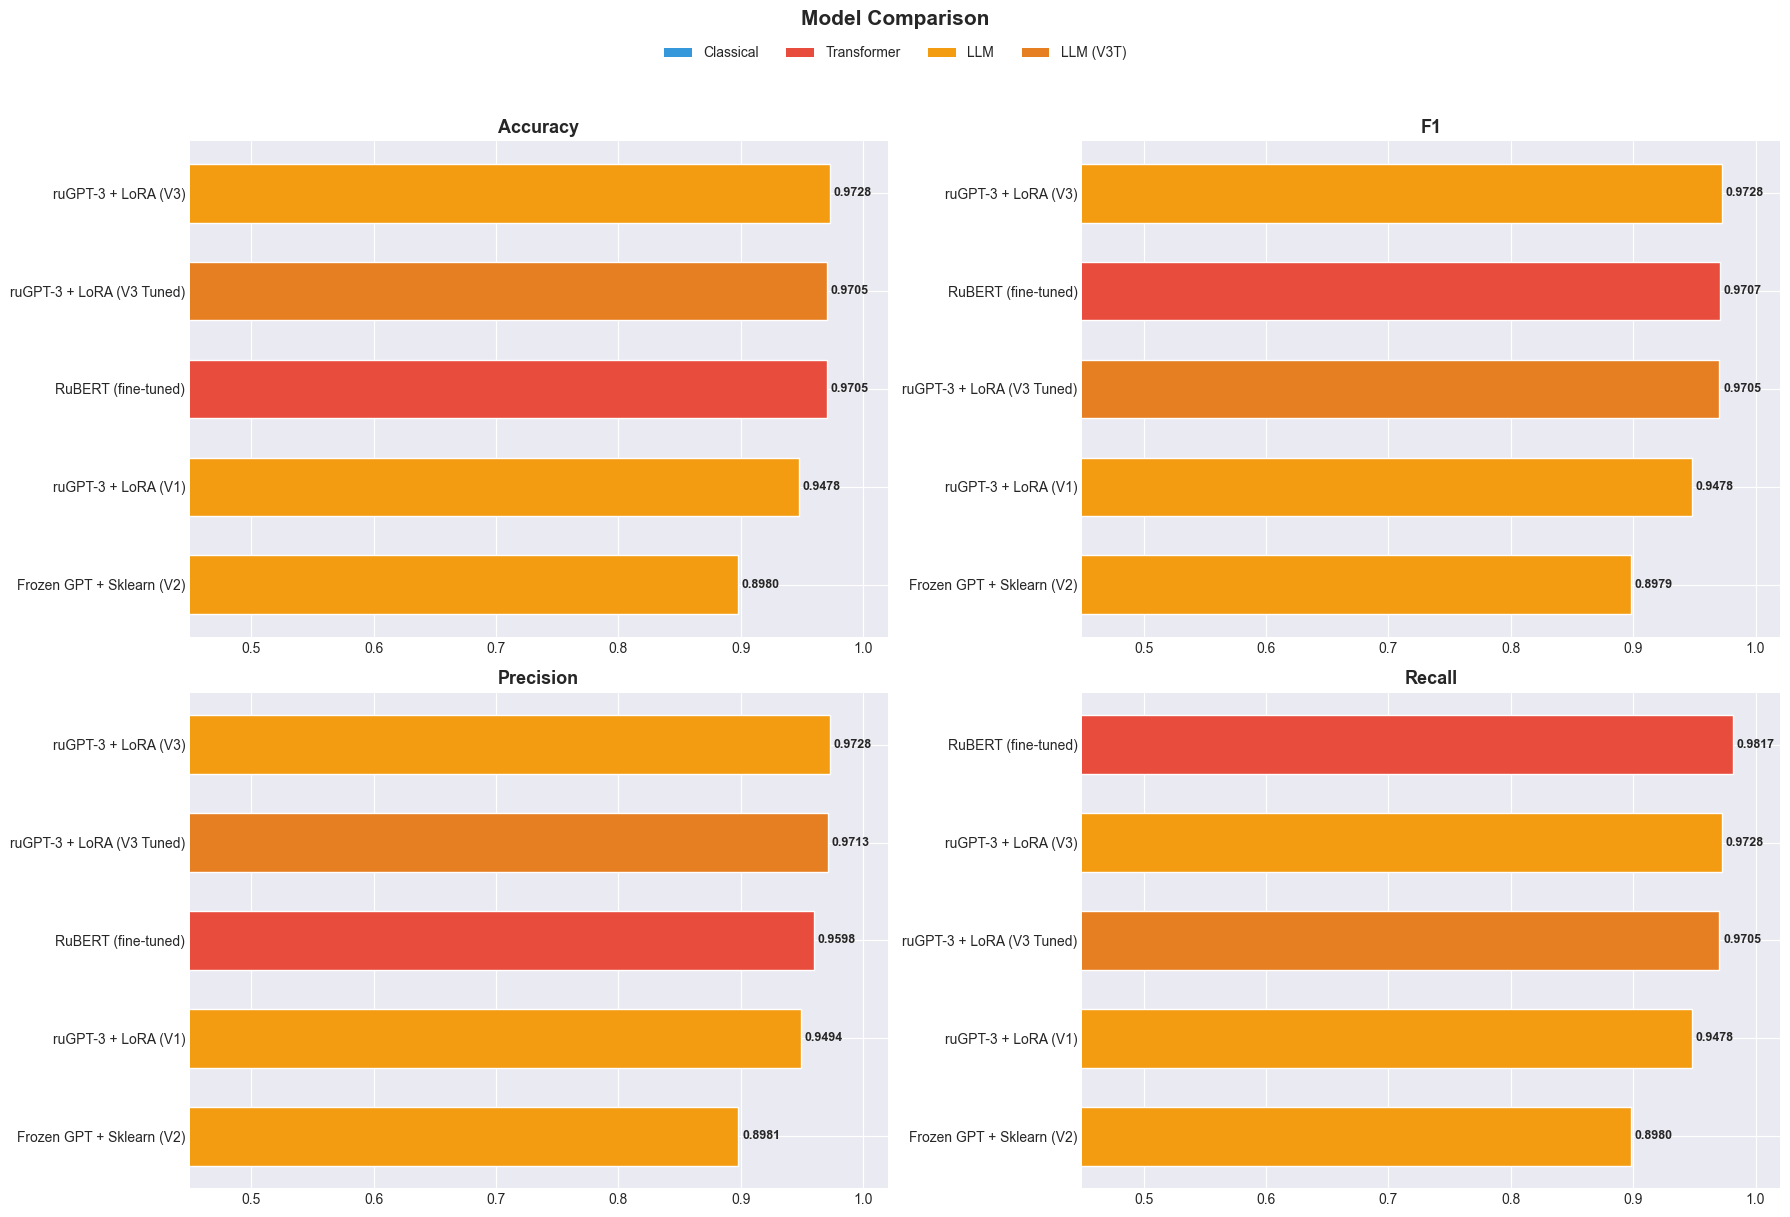

In [13]:
colors_map = {
    'Classical':    '#3498db',
    'Transformer':  '#e74c3c',
    'LLM':          '#f39c12',
    'LLM (V3T)':    '#e67e22',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric in [(axes[0,0],'Accuracy'), (axes[0,1],'F1'),
                    (axes[1,0],'Precision'), (axes[1,1],'Recall')]:
    plot_df = comparison_df.sort_values(metric, ascending=True)
    bars = ax.barh(plot_df['Model'], plot_df[metric],
                   color=[colors_map.get(m, '#999') for m in plot_df['Method']],
                   edgecolor='white', height=0.6)
    ax.set_xlim(0.45, 1.02)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=c, label=l) for l, c in colors_map.items()],
           loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.99))
plt.suptitle('Model Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, 'models_comparsion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save

In [14]:
with open(os.path.join(OUTPUT_DIR, 'metrics.json'), 'w', encoding='utf-8') as f:
    json.dump({
        'test': test_metrics,
        'history': history,
        'training_time_min': total_time / 60,
        'config': {
            'model': MODEL_NAME,
            'max_length': MAX_LENGTH,
            'lora_r': LORA_R,
            'lora_alpha': LORA_ALPHA,
            'lora_dropout': LORA_DROPOUT,
            'target_modules': TARGET_MODULES,
            'effective_batch': BATCH_SIZE * GRAD_ACCUM,
            'epochs': EPOCHS,
            'lr': LR,
            'label_smoothing': LABEL_SMOOTH,
            'class_weights': CLASS_WEIGHTS,
        },
    }, f, indent=4, ensure_ascii=False)

pred_df = test_df[[HEADLINE_COL, BODY_COL, LABEL_COL]].copy()
pred_df['pred']      = test_result['preds']
pred_df['prob_real'] = test_result['probs'][:, 1]
pred_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)

errors = test_result['preds'] != test_result['labels']
print(f'Correct: {(~errors).sum()}/{len(test_result["labels"])}')
print(f'FP: {((test_result["labels"]==0) & (test_result["preds"]==1)).sum()}')
print(f'FN: {((test_result["labels"]==1) & (test_result["preds"]==0)).sum()}')
print(f'Training time: {total_time/3600:.1f}h')

Correct: 428/441
FP: 11
FN: 2
Training time: 26.9h
